# Wine Classification using PyTorch
이 노트북은 와인 데이터를 분류하기 위해 두 가지 모델(Dense, 1D CNN)을 구현합니다.

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

In [ ]:
# 데이터 로드 및 타겟 값 조정 (1,2,3 -> 0,1,2)
df = pd.read_csv('wine.csv')
print("Columns:", df.columns)

# 타겟 분포 시각화
plt.figure(figsize=(8, 6))
df['Wine'].value_counts().plot(kind='pie', autopct='%0.2f%%', 
                               colors=['lightblue', 'lightgreen', 'orange'], 
                               explode=(0.05, 0.05, 0.05))
plt.title('Wine Class Distribution')
plt.show()

## [모델 1] Dense (MLP) 모델
가장 기본적인 완전 연결 계층(Fully Connected Layer) 모델입니다.

In [22]:
# 전처리
X_dense = df.drop('Wine', axis=1).values
y_dense = df['Wine'].values - 1

scaler = StandardScaler()
X_dense = scaler.fit_transform(X_dense)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dense, y_dense, test_size=0.2, random_state=42)

# 텐서 변환
X_train_d = torch.tensor(X_train_d, dtype=torch.float32)
y_train_d = torch.tensor(y_train_d, dtype=torch.int64)
X_test_d = torch.tensor(X_test_d, dtype=torch.float32)
y_test_d = torch.tensor(y_test_d, dtype=torch.int64)

train_loader_d = DataLoader(TensorDataset(X_train_d, y_train_d), batch_size=16, shuffle=True)
test_loader_d = DataLoader(TensorDataset(X_test_d, y_test_d), batch_size=16, shuffle=False)

In [23]:
class WineDenseModel(nn.Module):
    def __init__(self):
        super(WineDenseModel, self).__init__()
        self.fc1 = nn.Linear(13, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_d = WineDenseModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_d.parameters(), lr=0.01)

# 학습
epochs = 50
losses_d = []
for epoch in range(epochs):
    model_d.train()
    running_loss = 0.0
    for inputs, labels in train_loader_d:
        optimizer.zero_grad()
        outputs = model_d(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    losses_d.append(running_loss / len(train_loader_d))

print(f"Dense Model Final Loss: {losses_d[-1]:.4f}")

Dense Model Final Loss: 0.0000


## [모델 2] 1D CNN 모델
데이터를 시퀀스로 변환하여 합성곱 계층을 적용합니다.

In [24]:
def split_sequences(sequences, n_steps):
    X, y = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

n_steps = 5
combined_data = np.hstack((X_dense, y_dense.reshape(-1, 1)))
X_seq, y_seq = split_sequences(combined_data, n_steps)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

X_train_c = torch.tensor(X_train_c, dtype=torch.float32)
y_train_c = torch.tensor(y_train_c, dtype=torch.int64)
X_test_c = torch.tensor(X_test_c, dtype=torch.float32)
y_test_c = torch.tensor(y_test_c, dtype=torch.int64)

train_loader_c = DataLoader(TensorDataset(X_train_c, y_train_c), batch_size=16, shuffle=True)
test_loader_c = DataLoader(TensorDataset(X_test_c, y_test_c), batch_size=16, shuffle=False)

In [25]:
class WineCNN1D(nn.Module):
    def __init__(self, n_features, n_steps):
        super(WineCNN1D, self).__init__()
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * n_steps, 32)
        self.fc2 = nn.Linear(32, 3)
    
    def forward(self, x):
        x = x.permute(0, 2, 1) # (Batch, Step, Feature) -> (Batch, Feature, Step)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_c = WineCNN1D(n_features=13, n_steps=n_steps)
optimizer_c = optim.Adam(model_c.parameters(), lr=0.001)
losses_c = []

for epoch in range(epochs):
    model_c.train()
    running_loss = 0.0
    for inputs, labels in train_loader_c:
        optimizer_c.zero_grad()
        outputs = model_c(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c.step()
        running_loss += loss.item()
    losses_c.append(running_loss / len(train_loader_c))

print(f"CNN Model Final Loss: {losses_c[-1]:.4f}")

CNN Model Final Loss: 0.0000


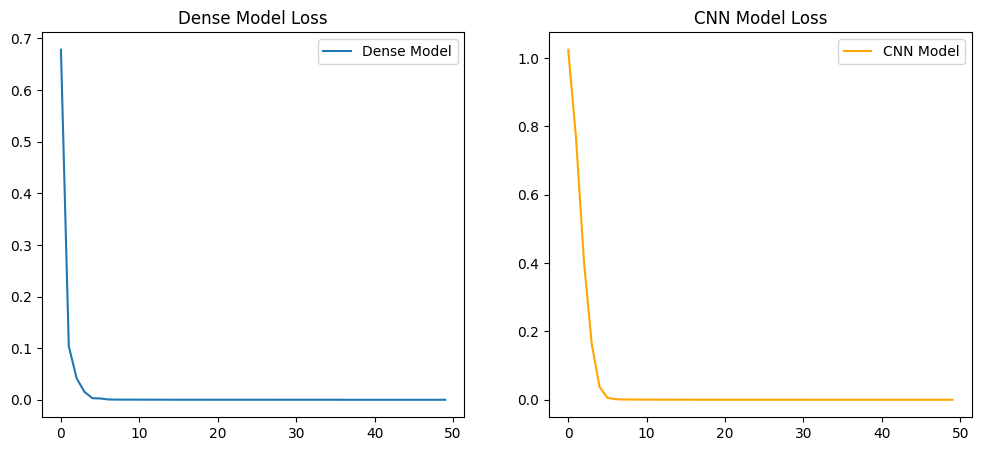

In [26]:
# 결과 비교 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_d, label='Dense Model')
plt.title('Dense Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(losses_c, label='CNN Model', color='orange')
plt.title('CNN Model Loss')
plt.legend()
plt.show()